In [1]:
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image

# Semilla para que los resultados sean reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


if torch.backends.mps.is_available():      # GPU de Apple (Mac M1/M2/M3...)
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():            # GPU NVIDIA
    DEVICE = torch.device("cuda")
else:                                      # CPU
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__} | Entrenaremos en: {DEVICE}")

PyTorch 2.14.0+cpu | Entrenaremos en: cpu


In [14]:
# DATA_DIR = Path("/content/drive/MyDrive/codiGO_by_Tecsup/workshop_2026_06_09/data/rock-paper-scissors")
DATA_DIR = Path("../data/rock-paper-scissors")

for carpeta in sorted(DATA_DIR.iterdir()):
    if carpeta.is_dir():
        n_imagenes = len(list(carpeta.glob("*.png")))
        print(f"{carpeta.name:>10s} → {n_imagenes} imágenes")

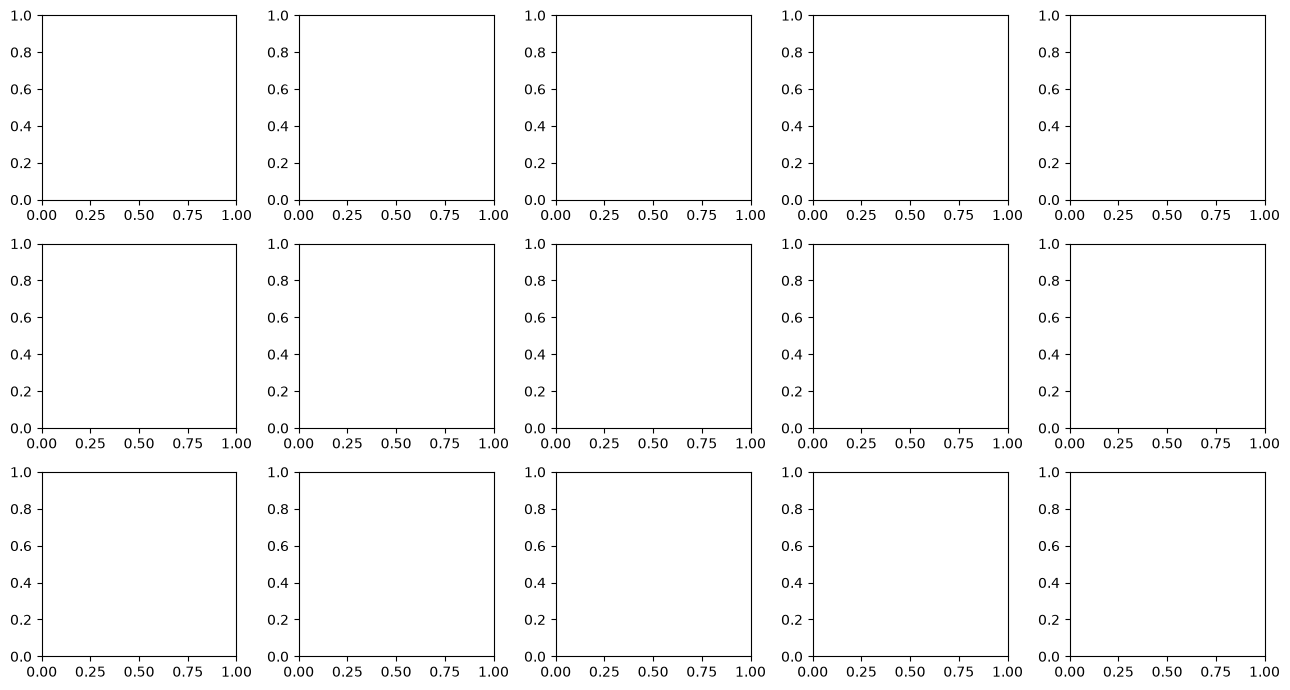

In [15]:
# Veamos 5 ejemplos de cada clase
clases_carpetas = ["rock", "paper", "scissors"]

fig, axes = plt.subplots(3, 5, figsize=(13, 7))
for fila, clase in enumerate(clases_carpetas):
    rutas = sorted((DATA_DIR / clase).glob("*.png"))[:5]
    for col, ruta in enumerate(rutas):
        axes[fila, col].imshow(Image.open(ruta))
        axes[fila, col].axis("off")
        if col == 0:
            axes[fila, col].set_title(clase, loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
IMG_SIZE_MLP = 32

transform_mlp = transforms.Compose([
    transforms.Resize((IMG_SIZE_MLP, IMG_SIZE_MLP)),
    transforms.ToTensor(),                       # imagen → tensor con valores [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],   # [0, 1] → [-1, 1]
                         std=[0.5, 0.5, 0.5]),
])

print(transform_mlp)

Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


In [2]:
BATCH_SIZE = 64

def crear_dataloaders(transform, batch_size=BATCH_SIZE):
    """Crea los DataLoaders de train/val/test con un transform dado.

    Usamos siempre la misma semilla, así los 3 modelos se evalúan
    exactamente con las mismas imágenes de test (comparación justa).
    """
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    n_total = len(dataset)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    n_test = n_total - n_train - n_val

    generador = torch.Generator().manual_seed(SEED)
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test], generator=generador
    )

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)
    test_dl = DataLoader(test_ds, batch_size=batch_size)
    return train_dl, val_dl, test_dl, dataset.classes


# train_dl_mlp, val_dl_mlp, test_dl_mlp, CLASES = crear_dataloaders(transform_mlp)

# print(f"Clases (orden alfabético): {CLASES}")
# print(f"Train: {len(train_dl_mlp.dataset)} | Val: {len(val_dl_mlp.dataset)} | Test: {len(test_dl_mlp.dataset)}")